In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

In [7]:
books   = pd.read_csv(r"C:\Users\Jasin\OneDrive\Desktop\book system\Books.csv",   sep=";", encoding="latin-1", on_bad_lines="skip", low_memory=False)
ratings = pd.read_csv(r"C:\Users\Jasin\OneDrive\Desktop\book system\Ratings.csv", sep=";", encoding="latin-1", on_bad_lines="skip")
users   = pd.read_csv(r"C:\Users\Jasin\OneDrive\Desktop\book system\Users.csv",   sep=";", encoding="latin-1", on_bad_lines="skip")
books   = pd.read_csv(r"C:\Users\Jasin\OneDrive\Desktop\book system\Books.csv",   encoding="latin-1", on_bad_lines="skip", low_memory=False, sep=",", quotechar='"')
ratings = pd.read_csv(r"C:\Users\Jasin\OneDrive\Desktop\book system\Ratings.csv", encoding="latin-1", on_bad_lines="skip", sep=",", quotechar='"')
users   = pd.read_csv(r"C:\Users\Jasin\OneDrive\Desktop\book system\Users.csv",   encoding="latin-1", on_bad_lines="skip", sep=",", quotechar='"')

books.columns   = ["ISBN", "Title", "Author", "Year", "Publisher", "Img-S", "Img-M", "Img-L"]
ratings.columns = ["User-ID", "ISBN", "Rating"]
users.columns   = ["User-ID", "Location", "Age"]

print(books.shape, ratings.shape, users.shape)

(271360, 8) (1149780, 3) (278858, 3)



── Books Sample ──
         ISBN                                              Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

                 Author  Year                   Publisher  \
0    Mark P. O. Morford  2002     Oxford University Press   
1  Richard Bruce Wright  2001       HarperFlamingo Canada   
2          Carlo D'Este  1991             HarperPerennial   
3      Gina Bari Kolata  1999        Farrar Straus Giroux   
4       E. J. W. Barber  1999  W. W. Norton &amp; Company   

                                               Img-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazon.com/images/P/0002005018.0...   
2  http://images.amazon.com/images/P

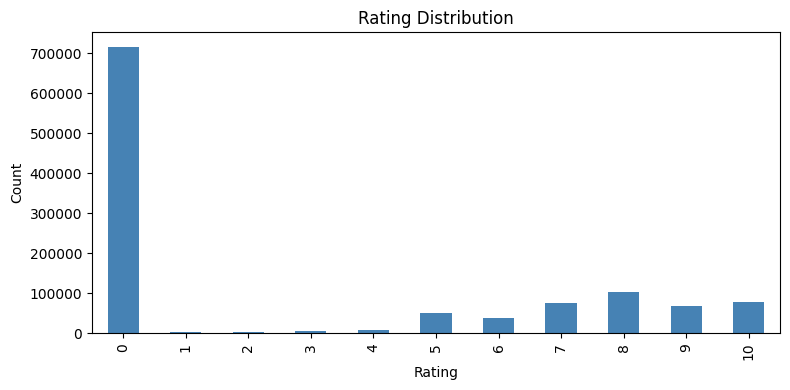

In [8]:
print("\n── Books Sample ──")
print(books.head())
 
print("\n── Missing Values ──")
print(books.isnull().sum())
 
plt.figure(figsize=(8, 4))
ratings["Rating"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("rating_distribution.png")
plt.show()